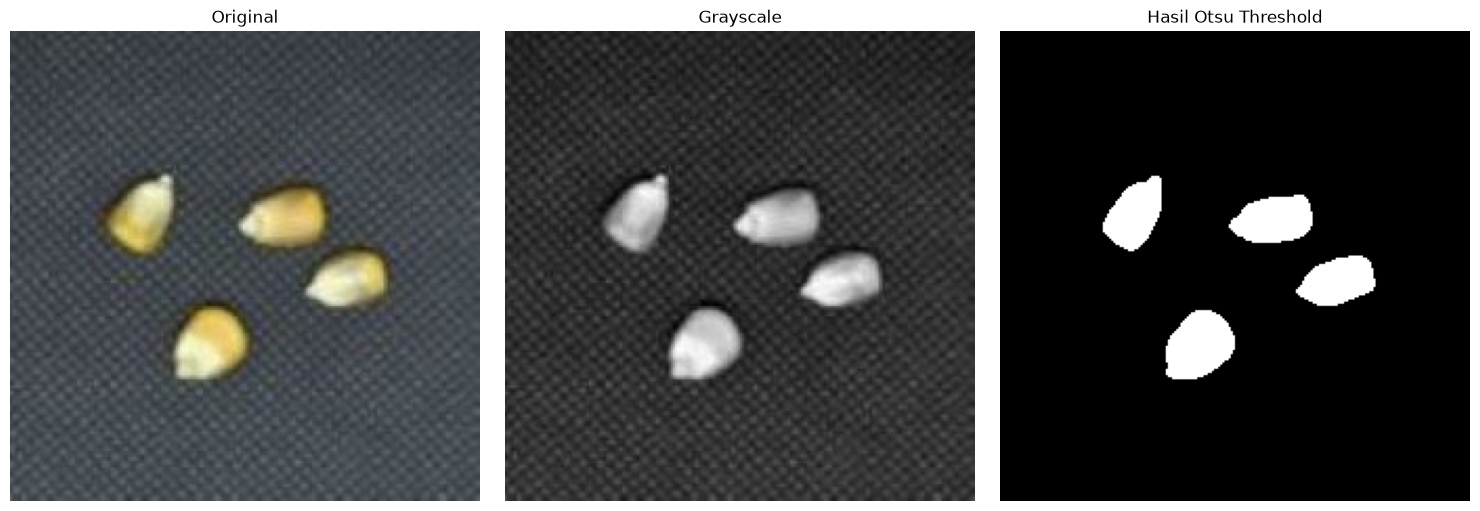

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img_path = "../data/raw/sehat/normal_002.JPG"
img = cv2.imread(img_path)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# 1: ubah ke grayscale
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 2: mengurangi noise dengan Gaussian Blur sebelum thresholding
# (5,5) = ukuran kernel blur, 0 = standar deviasi dihitung otomatis oleh OpenCV
blur = cv2.GaussianBlur(gray, (5, 5), 0)

# 3: Otsu thresholding
_, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_rgb)
axes[0].set_title("Original")
axes[1].imshow(gray, cmap='gray')
axes[1].set_title("Grayscale")
axes[2].imshow(thresh, cmap='gray')
axes[2].set_title("Hasil Otsu Threshold")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Jumlah kontur terdeteksi: 4
Jumlah biji valid (setelah filter noise): 4


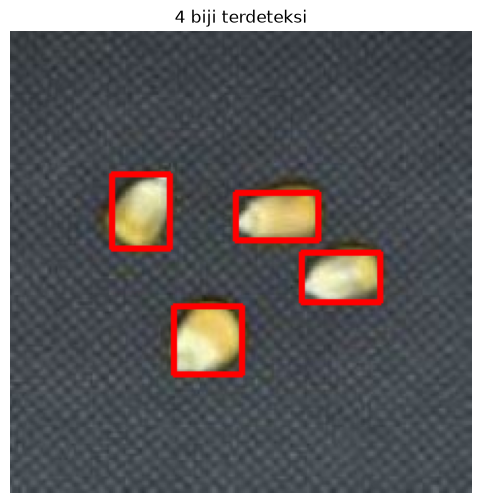

In [2]:
# 4: mencari kontur (garis tepi) dari tiap blob putih di hasil threshold
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
print(f"Jumlah kontur terdeteksi: {len(contours)}")

# 5: memfilter kontur yang terlalu kecil
MIN_AREA = 100
biji_contours = [c for c in contours if cv2.contourArea(c) > MIN_AREA]
print(f"Jumlah biji valid (setelah filter noise): {len(biji_contours)}")

# 6: menggambar bounding box di sekitar tiap biji untuk verifikasi visual
img_with_boxes = img_rgb.copy()
for c in biji_contours:
    x, y, w, h = cv2.boundingRect(c)
    cv2.rectangle(img_with_boxes, (x, y), (x + w, y + h), (255, 0, 0), 2)

plt.figure(figsize=(6, 6))
plt.imshow(img_with_boxes)
plt.title(f"{len(biji_contours)} biji terdeteksi")
plt.axis('off')
plt.show()

In [3]:
import os
import pandas as pd

os.makedirs("../data/cropped/sehat", exist_ok=True)
os.makedirs("../data/cropped/terkontaminasi", exist_ok=True)

MIN_AREA = 100
MAX_AREA = 700  # berdasarkan biji valid terbesar yang pernah ditemukan, + margin
MARGIN = 3

def deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    # Morphological Opening: memutus jembatan tipis & buang noise kecil,
    # sambil pertahankan ukuran objek yang selamat mendekati aslinya
    kernel_morph = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_morph, iterations=2)

    contours, _ = cv2.findContours(opened, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Filter DUA arah: buang yang terlalu kecil (noise) DAN yang terlalu besar
    # (artefak background atau tumpukan banyak biji menyatu)
    biji_contours = [c for c in contours if MIN_AREA < cv2.contourArea(c) < MAX_AREA]

    hasil = []
    h_img, w_img = img.shape[:2]

    for idx, c in enumerate(biji_contours):
        x, y, w, h = cv2.boundingRect(c)
        x1 = max(x - MARGIN, 0)
        y1 = max(y - MARGIN, 0)
        x2 = min(x + w + MARGIN, w_img)
        y2 = min(y + h + MARGIN, h_img)

        crop = img[y1:y2, x1:x2]

        nama_file_crop = f"{sumber_nama}_biji{idx+1}.jpg"
        path_simpan = os.path.join(folder_tujuan, nama_file_crop)
        cv2.imwrite(path_simpan, crop)

        hasil.append({
            "filename": nama_file_crop,
            "source_file": sumber_nama,
            "label": label,
            "area_piksel": cv2.contourArea(c),
            "width": x2 - x1,
            "height": y2 - y1
        })

    return hasil

manifest = []

for label, path_folder, folder_tujuan in [
    ("sehat", "../data/raw/sehat", "../data/cropped/sehat"),
    ("terkontaminasi", "../data/raw/terkontaminasi", "../data/cropped/terkontaminasi"),
]:
    daftar_file = os.listdir(path_folder)
    for nama_file in daftar_file:
        img_path = os.path.join(path_folder, nama_file)
        sumber_nama = os.path.splitext(nama_file)[0]
        hasil_crop = deteksi_dan_crop(img_path, label, folder_tujuan, sumber_nama)
        manifest.extend(hasil_crop)

df_manifest = pd.DataFrame(manifest)
df_manifest.to_csv("../data/manifest_crop.csv", index=False)

print(f"Total crop dihasilkan: {len(df_manifest)}")
print(df_manifest["label"].value_counts())

Total crop dihasilkan: 207
label
sehat             118
terkontaminasi     89
Name: count, dtype: int64


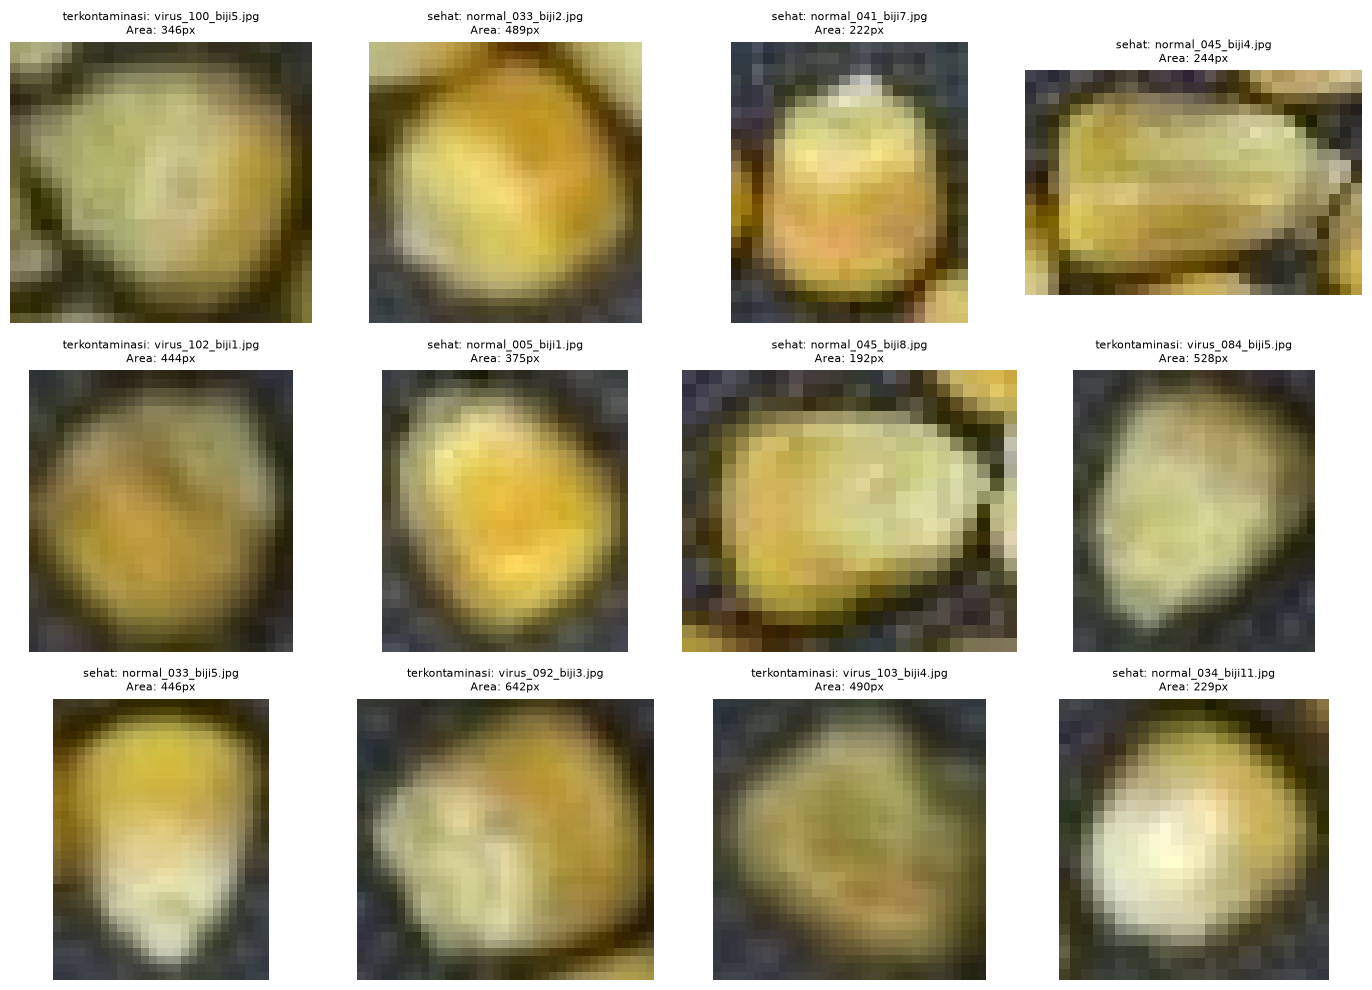

In [4]:
import random

# Ambil 12 sampel acak (campur kedua label) untuk verifikasi visual sekilas
random.seed(42)
sampel_acak = df_manifest.sample(n=12, random_state=42)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

for i, (_, row) in enumerate(sampel_acak.iterrows()):
    folder = "../data/cropped/sehat" if row["label"] == "sehat" else "../data/cropped/terkontaminasi"
    img_path = os.path.join(folder, row["filename"])
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img_rgb)
    axes[i].set_title(f"{row['label']}: {row['filename']}\nArea: {row['area_piksel']:.0f}px", fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()